# 9. Análisis Exploratorio de Datos (EDA) - PolypSegm-ASH

**Objetivo:** Conocer el "enemigo". Saber qué tipo de imágenes vamos a procesar.

**Qué buscar:**
- ¿Son TIFF pesados o JPG comprimidos?
- ¿Tienen todas el mismo tamaño o varían?
- ¿Hay artefactos extraños (letras sobreimpresas, bordes verdes, etc.)?
- Revisar metadatos: ¿Hay datos sensibles del paciente en el EXIF/DICOM?
- Visualizar 5-10 imágenes aleatorias para entender la dificultad (brillos, oscuridad)

In [15]:
import os
import time
import zipfile
import shutil
from pathlib import Path
from PIL import Image
from PIL.ExifTags import TAGS
import matplotlib.pyplot as plt
import random
import pandas as pd
import numpy as np

# Configurar rutas
data_root = Path('../data/raw')
expected_splits = ['m_train', 'm_valid', 'm_test']
root_zip_candidates = [
    data_root / 'polypsegm-ash.zip',
    Path('../data') / 'polypsegm-ash.zip',
]


def extract_zip(zip_path: Path, destination: Path) -> None:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(destination)


def remove_archive_if_redundant(archive_path: Path, extracted_folder: Path, retries: int = 3, wait_s: float = 0.5) -> None:
    if not (archive_path.exists() and extracted_folder.exists() and extracted_folder.is_dir() and any(extracted_folder.iterdir())):
        return

    for attempt in range(1, retries + 1):
        try:
            archive_path.unlink()
            print(f"Eliminado comprimido ya extraído: {archive_path.name}")
            return
        except PermissionError:
            if attempt < retries:
                time.sleep(wait_s)
            else:
                print(
                    f"⚠️ No se pudo eliminar {archive_path.name} porque está en uso. "
                    "Ciérralo (explorador/visor) y vuelve a ejecutar si quieres borrarlo."
                )
        except Exception as e:
            print(f"⚠️ No se pudo eliminar {archive_path.name}: {e}")
            return


def looks_like_dataset_root(path: Path) -> bool:
    if not path.is_dir():
        return False

    has_split_folder = any((path / split).exists() for split in expected_splits)
    has_split_archive = any((path / f'{split}.rar').exists() or (path / f'{split}.zip').exists() for split in expected_splits)
    has_test_csv = (path / 'gt_test.csv').exists() or (path / 'm_test' / 'gt_test.csv').exists()

    return has_split_folder or has_split_archive or has_test_csv


def detect_dataset_root(base: Path) -> Path | None:
    # Prioridad 1: ruta canónica
    canonical = base / 'polypsegm-ash'
    if looks_like_dataset_root(canonical):
        return canonical

    # Prioridad 2: raíz directa (cuando el ZIP trae todo en top-level)
    if looks_like_dataset_root(base):
        return base

    # Prioridad 3: carpetas hijas
    for child in sorted([p for p in base.iterdir() if p.is_dir()]):
        if looks_like_dataset_root(child):
            return child

    return None


# 1) Detectar dataset; si no existe, extraer ZIP principal
current_data_dir = detect_dataset_root(data_root)
if current_data_dir is None:
    root_zip = next((p for p in root_zip_candidates if p.exists()), None)
    if root_zip is None:
        raise FileNotFoundError(
            "No se encontró 'polypsegm-ash.zip' en ../data/raw ni en ../data."
        )

    print(f"Extrayendo dataset raíz desde: {root_zip}")
    extract_zip(root_zip, data_root)

    current_data_dir = detect_dataset_root(data_root)
    if current_data_dir is None:
        top_level = [p.name for p in sorted(data_root.iterdir())]
        raise FileNotFoundError(
            "No se pudo detectar la raíz del dataset tras extraer el ZIP. "
            f"Contenido en {data_root}: {top_level}"
        )

    # Si quedó correctamente extraído, intentamos eliminar el zip raíz
    remove_archive_if_redundant(root_zip, current_data_dir)
else:
    print(f"Dataset raíz ya disponible en: {current_data_dir}")


data_dir = current_data_dir


# 2) Resolver ZIPs anidados en cualquier nivel y eliminarlos si ya están extraídos
nested_zips = sorted([p for p in data_dir.rglob('*.zip') if p.is_file()])
if nested_zips:
    for nested_zip in nested_zips:
        target_folder = nested_zip.with_suffix('')
        if target_folder.exists() and any(target_folder.iterdir()):
            print(f"Saltando extracción de {nested_zip.name}: '{target_folder.name}' ya existe.")
        else:
            print(f"Extrayendo ZIP anidado: {nested_zip.relative_to(data_dir)}")
            extract_zip(nested_zip, data_dir)

        remove_archive_if_redundant(nested_zip, target_folder)
else:
    print("No se detectaron ZIPs anidados en el dataset.")


# 3) Resolver RARs anidados y eliminarlos si ya están extraídos
nested_rars = sorted([p for p in data_dir.rglob('*.rar') if p.is_file()])
if nested_rars:
    try:
        import rarfile  # requiere 'rarfile' y una herramienta externa (unrar/bsdtar/unar)
        for nested_rar in nested_rars:
            target_folder = nested_rar.with_suffix('')
            if target_folder.exists() and any(target_folder.iterdir()):
                print(f"Saltando extracción de {nested_rar.name}: '{target_folder.name}' ya existe.")
            else:
                print(f"Extrayendo RAR anidado: {nested_rar.relative_to(data_dir)}")
                # Extraer en la raíz del dataset para evitar rutas tipo m_test/m_test/*
                with rarfile.RarFile(nested_rar) as rar_ref:
                    rar_ref.extractall(data_dir)

            remove_archive_if_redundant(nested_rar, target_folder)
    except Exception as e:
        print("⚠️ No se pudieron extraer archivos .rar automáticamente.")
        print("   Instala 'rarfile' y una herramienta del sistema (unrar/bsdtar/unar),")
        print("   o extrae manualmente m_test.rar y m_valid.rar en carpetas m_test/m_valid.")
        print(f"   Detalle: {e}")
else:
    print("No se detectaron RARs anidados en el dataset.")


# 4) Mover gt_test.csv a m_test/gt_test.csv
root_gt_test = data_dir / 'gt_test.csv'
target_m_test_dir = data_dir / 'm_test'
target_gt_test = target_m_test_dir / 'gt_test.csv'

if root_gt_test.exists():
    target_m_test_dir.mkdir(parents=True, exist_ok=True)
    if target_gt_test.exists():
        print("gt_test.csv ya existe en m_test; no se sobrescribe.")
    else:
        shutil.move(str(root_gt_test), str(target_gt_test))
        print(f"Movido gt_test.csv a: {target_gt_test}")
else:
    if target_gt_test.exists():
        print("gt_test.csv ya está dentro de m_test.")
    else:
        print("⚠️ No se encontró gt_test.csv ni en raíz ni en m_test.")


# 5) Validación mínima de estructura esperada
missing_splits = [split for split in expected_splits if not (data_dir / split).exists()]
if missing_splits:
    print(f"⚠️ Faltan carpetas esperadas tras extracción: {missing_splits}")

# Cargar rutas de imágenes para EDA
image_paths = list(data_dir.rglob('images/*.*'))
print(f'Ruta detectada del dataset: {data_dir}')
print(f'Total de imágenes encontradas: {len(image_paths)}')

Extrayendo dataset raíz desde: ..\data\polypsegm-ash.zip
Eliminado comprimido ya extraído: polypsegm-ash.zip
No se detectaron ZIPs anidados en el dataset.
Extrayendo RAR anidado: m_test.rar
Eliminado comprimido ya extraído: m_test.rar
Saltando extracción de m_train.rar: 'm_train' ya existe.
Eliminado comprimido ya extraído: m_train.rar
Extrayendo RAR anidado: m_valid.rar
Eliminado comprimido ya extraído: m_valid.rar
Movido gt_test.csv a: ..\data\raw\m_test\gt_test.csv
Ruta detectada del dataset: ..\data\raw
Total de imágenes encontradas: 1126


## 1. Verificar formato de archivo y resoluciones

In [16]:
formats = set()
resolutions = set()
resolution_counts = {}

for img_path in image_paths:
    try:
        with Image.open(img_path) as img:
            formats.add(img.format)
            res = img.size
            resolutions.add(res)
            resolution_counts[res] = resolution_counts.get(res, 0) + 1
    except Exception as e:
        print(f'Error leyendo {img_path}: {e}')

print(f'Formatos encontrados: {formats}')
print(f'Resoluciones únicas: {len(resolutions)}')
print('\nDistribución de resoluciones:')
for res, count in sorted(resolution_counts.items(), key=lambda x: x[1], reverse=True):
    print(f'  - {res[0]}x{res[1]}: {count} imágenes')

Formatos encontrados: {'TIFF'}
Resoluciones únicas: 4

Distribución de resoluciones:
  - 1920x1080: 1020 imágenes
  - 1280x1024: 76 imágenes
  - 1350x1080: 29 imágenes
  - 1280x1008: 1 imágenes


## 2. Revisar metadatos (EXIF)
Buscamos si hay datos sensibles del paciente en el EXIF.

In [17]:
exif_tags_found = set()
sensitive_tags = ['PatientName', 'PatientID', 'StudyDate', 'DateTimeOriginal', 'Artist', 'Copyright']
found_sensitive_data = False

for img_path in image_paths[:100]: # Revisamos una muestra representativa
    try:
        with Image.open(img_path) as img:
            exif = img.getexif()
            if exif:
                for tag_id, value in exif.items():
                    tag = TAGS.get(tag_id, tag_id)
                    exif_tags_found.add(tag)
                    if tag in sensitive_tags:
                        print(f'¡ALERTA! Dato sensible encontrado en {img_path.name}: {tag} = {value}')
                        found_sensitive_data = True
    except Exception as e:
        pass

print(f'Etiquetas EXIF únicas encontradas en la muestra: {exif_tags_found}')
if not found_sensitive_data:
    print('\n✅ No se encontraron datos sensibles del paciente en los metadatos EXIF revisados.')

Etiquetas EXIF únicas encontradas en la muestra: {'RowsPerStrip', 'Predictor', 'WhitePoint', 'PrimaryChromaticities', 'SampleFormat', 'StripByteCounts', 'PhotometricInterpretation', 'PlanarConfiguration', 'FillOrder', 'BitsPerSample', 'PageNumber', 'Orientation', 'ImageWidth', 'ResolutionUnit', 'SamplesPerPixel', 'StripOffsets', 'Compression', 'ImageLength'}

✅ No se encontraron datos sensibles del paciente en los metadatos EXIF revisados.


## 3. Visualizar imágenes aleatorias
Visualizamos 10 imágenes aleatorias para entender la dificultad (brillos, oscuridad, artefactos).

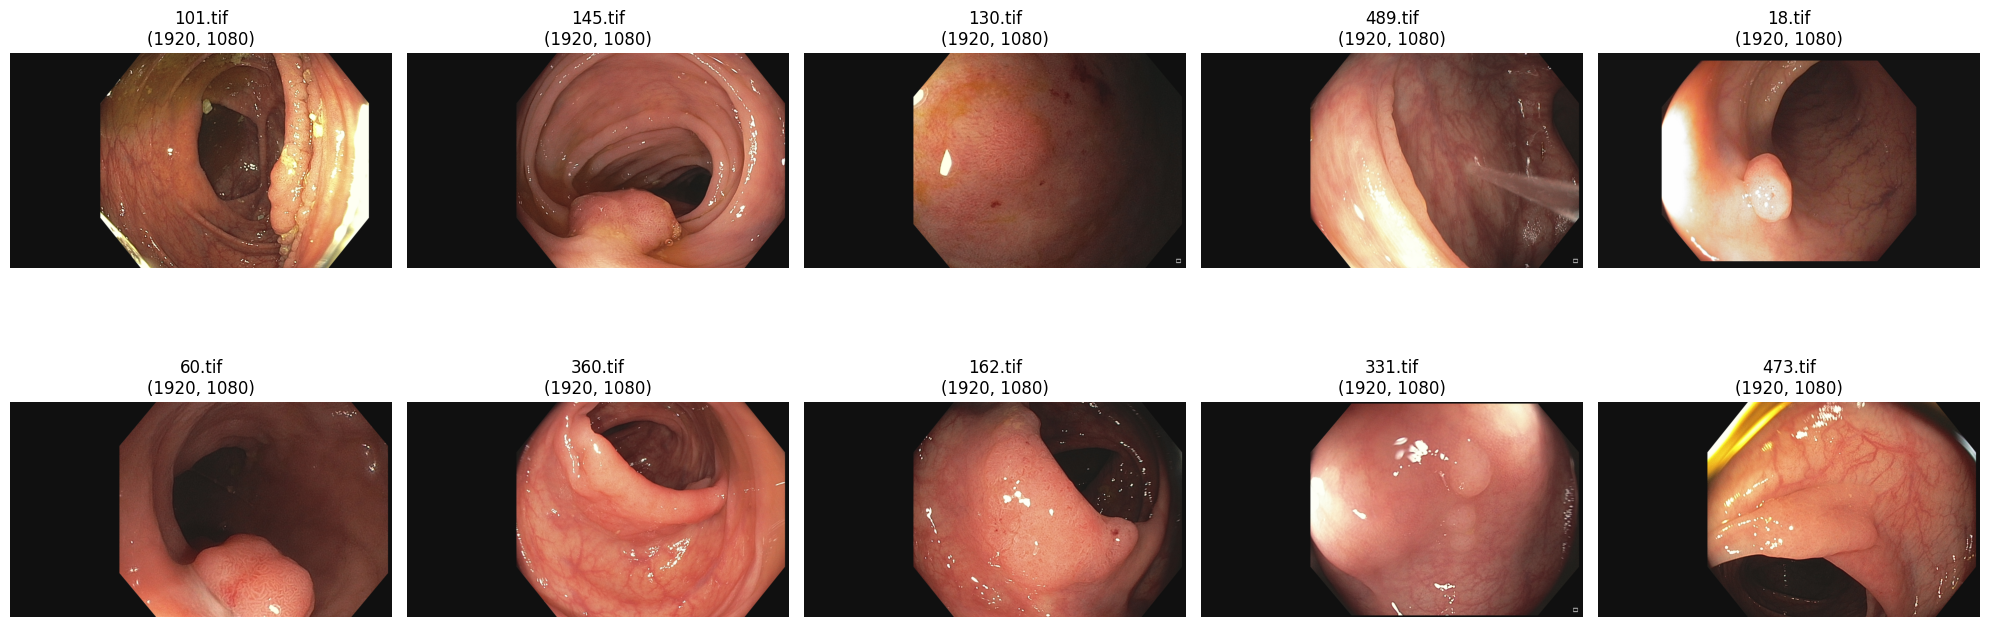

In [18]:
num_images_to_show = 10
random_images = random.sample(image_paths, min(num_images_to_show, len(image_paths)))

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, img_path in enumerate(random_images):
    try:
        with Image.open(img_path) as img:
            axes[i].imshow(img)
            axes[i].set_title(f'{img_path.name}\n{img.size}')
            axes[i].axis('off')
    except Exception as e:
        axes[i].set_title('Error')
        axes[i].axis('off')

plt.tight_layout()
plt.show()

## 4. Ejecutar preprocesado completo
Ejecuta el script de preprocesado sobre **todas** las imágenes y guarda resultados en `data/processed`.  
Nota: el pipeline también duplica automáticamente los CSV de partición (`train.csv`, `valid.csv`, `gt_test.csv`) desde `data/raw` a `data/processed` para mantener consistencia en los splits.

In [21]:
import subprocess
import sys
from pathlib import Path

cmd = [
    sys.executable,
    str(Path('../src/preprocessing/preprocess.py')),
    '--input-dir',
    str(Path('../data/raw')),
    '--output-dir',
    str(Path('../data/processed')),
]

print('Ejecutando comando:')
print(' '.join(cmd))

result = subprocess.run(cmd, capture_output=True, text=True)

print('\n--- STDOUT ---')
print(result.stdout if result.stdout else '(sin salida)')

if result.stderr:
    print('\n--- STDERR ---')
    print(result.stderr)

if result.returncode != 0:
    raise RuntimeError(f'El preprocesado falló con código {result.returncode}')

print('\n✅ Preprocesado completo finalizado correctamente.')

Ejecutando comando:
c:\Users\david\Desktop\TFG\TFG_VLM_Medical\.venv\Scripts\python.exe ..\src\preprocessing\preprocess.py --input-dir ..\data\raw --output-dir ..\data\processed

--- STDOUT ---

=== Resumen de preprocesado ===
Entrada: ..\data\raw
Salida: ..\data\processed
ImÃ¡genes procesadas: 2027
ImÃ¡genes recortadas: 1532
ImÃ¡genes sin cambios: 495
CSV duplicados: 3
Modo dry-run: no


✅ Preprocesado completo finalizado correctamente.


## 5. Comparativa antes/después del preprocesado
Visualización rápida de 5 imágenes para comprobar el recorte de bordes negros.

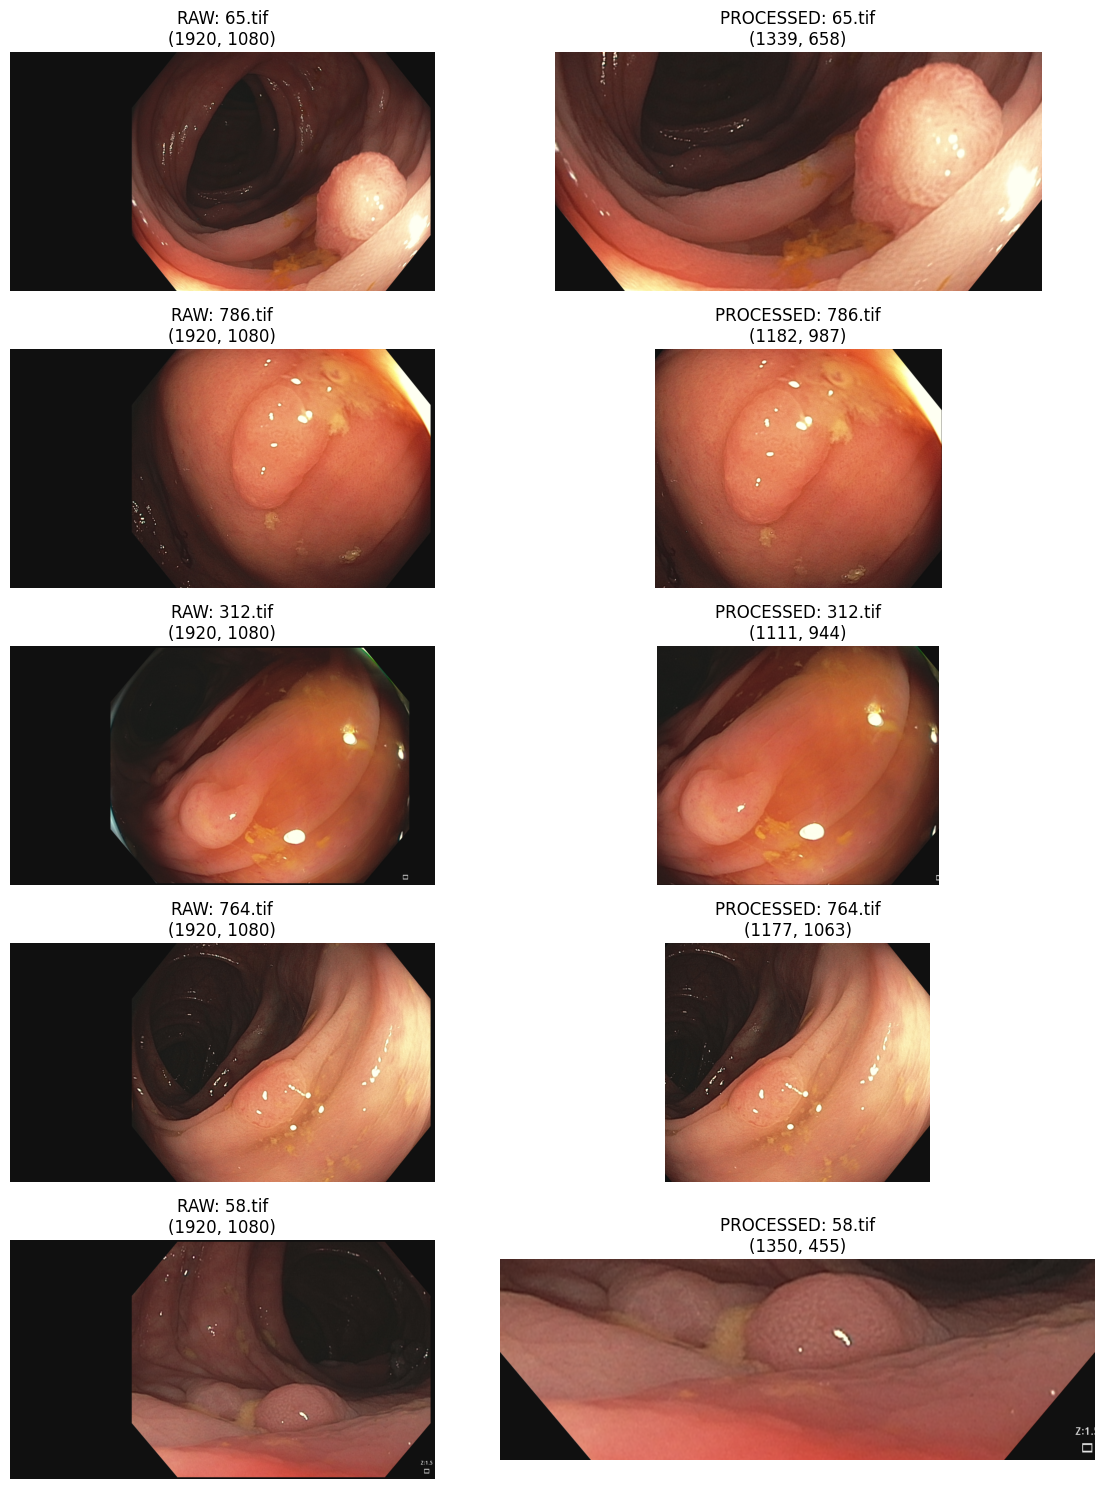

In [22]:
from pathlib import Path
import random
from PIL import Image
import matplotlib.pyplot as plt

raw_root = Path('../data/raw')
processed_root = Path('../data/processed')

raw_images = list(raw_root.rglob('images/*.*'))
comparables = []

for raw_path in raw_images:
    rel = raw_path.relative_to(raw_root)
    processed_path = processed_root / rel
    if processed_path.exists():
        comparables.append((raw_path, processed_path))

if not comparables:
    raise RuntimeError('No se encontraron pares raw/processed para comparar.')

sample_size = min(5, len(comparables))
sample_pairs = random.sample(comparables, sample_size)

fig, axes = plt.subplots(sample_size, 2, figsize=(12, 3 * sample_size))
if sample_size == 1:
    axes = [axes]

for idx, (raw_path, proc_path) in enumerate(sample_pairs):
    with Image.open(raw_path) as raw_img:
        axes[idx][0].imshow(raw_img)
        axes[idx][0].set_title(f'RAW: {raw_path.name}\n{raw_img.size}')
        axes[idx][0].axis('off')

    with Image.open(proc_path) as proc_img:
        axes[idx][1].imshow(proc_img)
        axes[idx][1].set_title(f'PROCESSED: {proc_path.name}\n{proc_img.size}')
        axes[idx][1].axis('off')

plt.tight_layout()
plt.show()